# Dataset01 Customers

## 1.1 Outlier Detection & Analysis

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned/cleaned_customersDF.csv") 
df.head()


,first_name,last_name,email,phone,age,city,registration_date,customer_segment,credit_score,total_spent,customer_id
0,Danielle,Johnson,john21@example.net,001-581-896-0013x3890,40.0,Annaba,2024-03-18,Standard,636.0,6786.35,CUST_00000
1,Joshua,Booth,helenpeterson@example.org,651.216.1559,29.0,Sidi Bel Abbès,2024-06-21,Standard,704.0,11496.74,CUST_00001
2,Teresa,Gray,maria95@example.net,610.934.1316,24.0,Batna,2023-05-09,Standard,508.0,5959.11,CUST_00002
3,Michael,Santiago,lynchgeorge@example.net,527.264.8350,27.0,BATNA,2024-01-25,Standard,620.0,16259.63,CUST_00003
4,Carl,Gentry,jason76@example.net,724.523.8849x696,37.0,Constantine,2024-05-23,Standard,454.0,3706.01,CUST_00004


In [134]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols


['age', 'credit_score', 'total_spent']

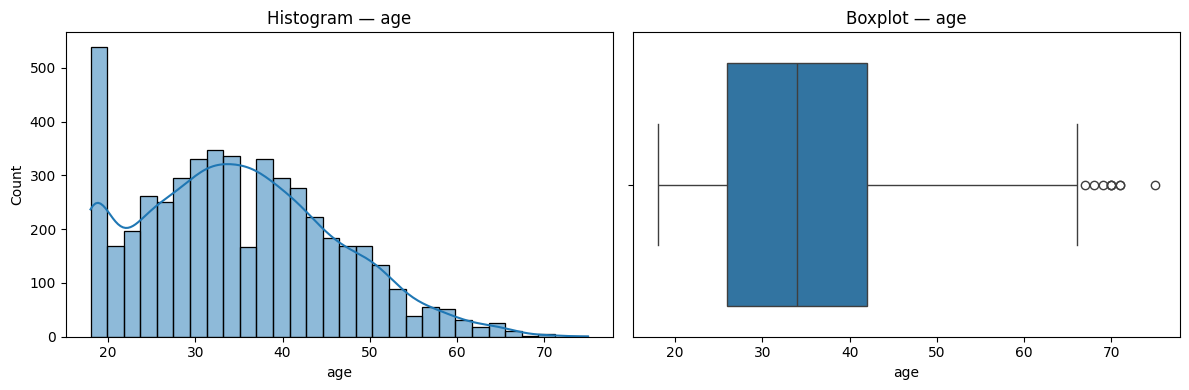

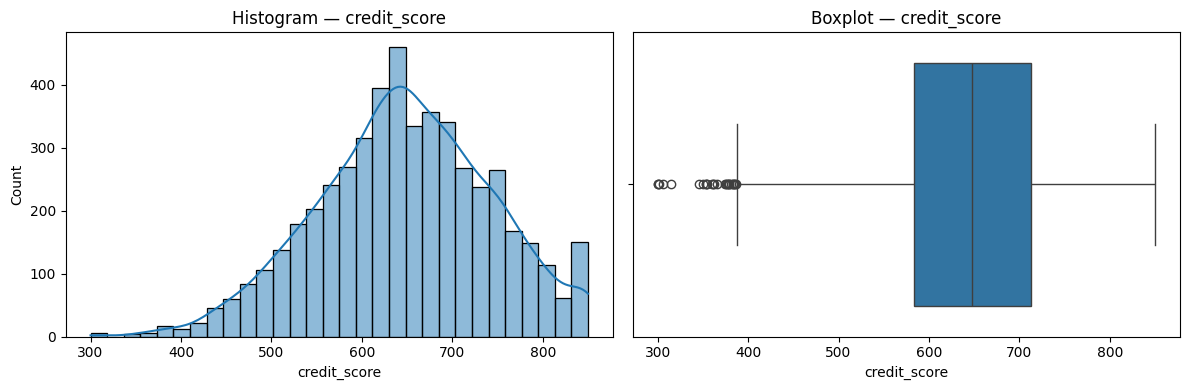

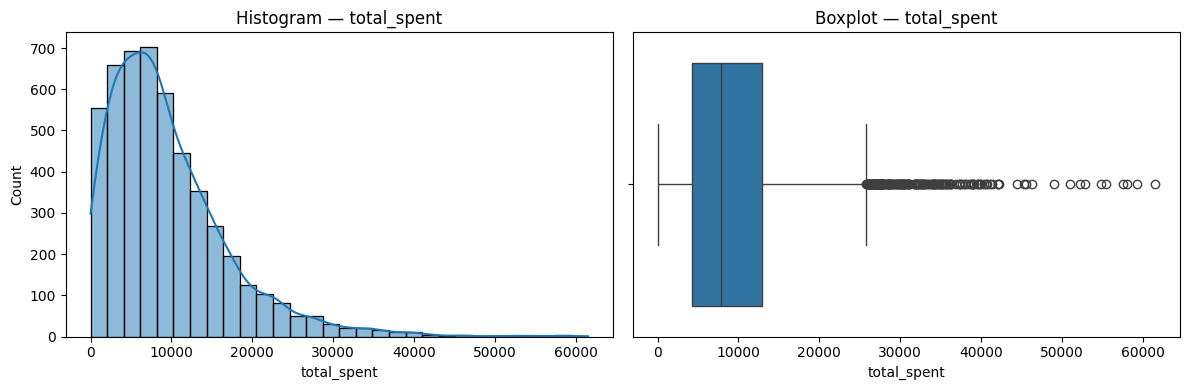

In [135]:
for col in numeric_cols:
    plt.figure(figsize=(12,4))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram — {col}")

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot — {col}")

    plt.tight_layout()
    plt.show()


In [136]:
iqr_results = []

for col in numeric_cols:
    data = df[col].dropna()

    # Quartiles
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Outliers
    mask_iqr = (df[col] < lower_bound) | (df[col] > upper_bound)
    n_outliers = mask_iqr.sum()

    iqr_results.append([col, len(data), Q1, Q3, IQR, lower_bound, upper_bound, n_outliers])

iqr_df = pd.DataFrame(iqr_results, columns=[
    "Feature", "Count", "Q1", "Q3", "IQR", "Lower Bound", "Upper Bound", "IQR Outliers"
])

iqr_df


,Feature,Count,Q1,Q3,IQR,Lower Bound,Upper Bound,IQR Outliers
0,age,5000,26.0000,42.00,16.0000,2.00000,66.00000,9
1,credit_score,5000,583.0000,713.00,130.0000,388.00000,908.00000,26
2,total_spent,5000,4208.2325,12856.37,8648.1375,-8763.97375,25828.57625,194


In [ ]:
zscore_results = []

for col in numeric_cols:
    data = df[col].dropna()

    median = data.median()
    mad = np.median(np.abs(data - median))

    if mad == 0:
        outlier_count = 0
    else:
        z = 0.6745 * (data - median) / mad
        mask_z = np.abs(z) > 3.5
        outlier_count = mask_z.sum()

    zscore_results.append([col, median, mad, outlier_count])

robustz_df = pd.DataFrame(zscore_results, columns=[
    "Feature", "Median", "MAD", "Robust Z Outliers"
])

robustz_df


,Feature,Median,MAD,Robust Z Outliers
0,age,34.000,8.00,0
1,credit_score,648.000,65.00,4
2,total_spent,7864.635,4183.99,114


In [138]:
outlier_report = pd.merge(iqr_df, robustz_df, on="Feature")
outlier_report


,Feature,Count,Q1,Q3,IQR,Lower Bound,Upper Bound,IQR Outliers,Median,MAD,Robust Z Outliers
0,age,5000,26.0000,42.00,16.0000,2.00000,66.00000,9,34.000,8.00,0
1,credit_score,5000,583.0000,713.00,130.0000,388.00000,908.00000,26,648.000,65.00,4
2,total_spent,5000,4208.2325,12856.37,8648.1375,-8763.97375,25828.57625,194,7864.635,4183.99,114


## 1.2 Outlier Treatment

In [139]:
median_age = df["age"].median()

df.loc[df["age"] < 2, "age"] = median_age


## 1.3 Data Transformation

In [140]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df_transformed = df.copy()


In [141]:
scaler_standard = StandardScaler()

cols_to_standardize = ["age", "credit_score"]
scaled_data = scaler_standard.fit_transform(df_transformed[cols_to_standardize])

df_transformed["age_standardized"] = scaled_data[:, 0]
df_transformed["credit_score_standardized"] = scaled_data[:, 1]


In [142]:
df_transformed['total_spent_log'] = np.log1p(df['total_spent'])

In [143]:
df_transformed[[
    "age", "age_standardized",
    "credit_score", "credit_score_standardized",
    "total_spent", "total_spent_log",
]].head()


,age,age_standardized,credit_score,credit_score_standardized,total_spent,total_spent_log
0,40.0,0.468162,636.0,-0.115638,6786.35,8.822816
1,29.0,-0.519559,704.0,0.588560,11496.74,9.349906
2,24.0,-0.968523,508.0,-1.441187,5959.11,8.692844
3,27.0,-0.699144,620.0,-0.281331,16259.63,9.696502
4,37.0,0.198783,454.0,-2.000403,3706.01,8.217981


## 1.4 Impact Analysis

In [145]:
df_before = df[["age", "credit_score", "total_spent"]]
df_after = df_transformed[[
    "age_standardized",
    "credit_score_standardized",
    "total_spent_log"
]]

print("=== BEFORE TRANSFORMATION ===")
display(df_before.describe())

print("\n=== AFTER TRANSFORMATION ===")
display(df_after.describe())


=== BEFORE TRANSFORMATION ===


,age,credit_score,total_spent
count,5000.000000,5000.000000,5000.000000
mean,34.786200,647.166400,9500.082820
std,11.137868,96.573396,7513.079011
min,18.000000,300.000000,0.000000
25%,26.000000,583.000000,4208.232500
50%,34.000000,648.000000,7864.635000
75%,42.000000,713.000000,12856.370000
max,75.000000,850.000000,61548.140000



=== AFTER TRANSFORMATION ===


,age_standardized,credit_score_standardized,total_spent_log
count,5.000000e+03,5.000000e+03,5000.000000
mean,-8.313350e-17,4.817480e-16,8.610734
std,1.000100e+00,1.000100e+00,1.738560
min,-1.507279e+00,-3.595205e+00,0.000000
25%,-7.889372e-01,-6.644979e-01,8.345036
50%,-7.059508e-02,8.632640e-03,8.970259
75%,6.477471e-01,6.817632e-01,9.461672
max,3.610909e+00,2.100515e+00,11.027591


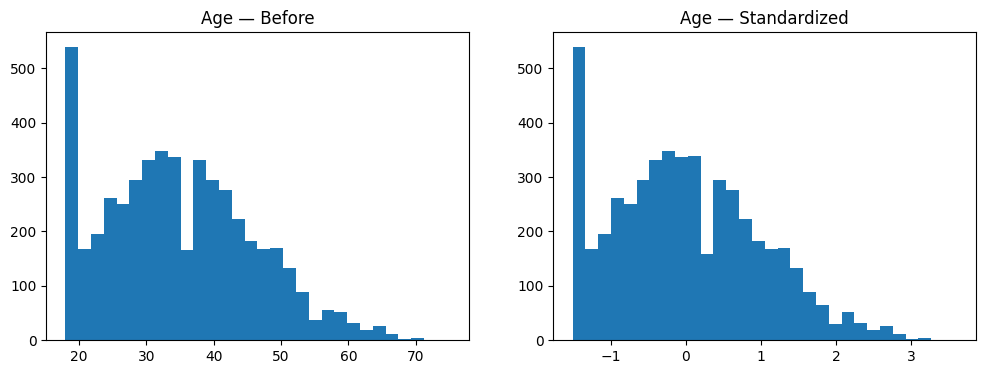

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df["age"], bins=30)
plt.title("Age — Before")

plt.subplot(1,2,2)
plt.hist(df_transformed["age_standardized"], bins=30)
plt.title("Age — Standardized")

plt.show()


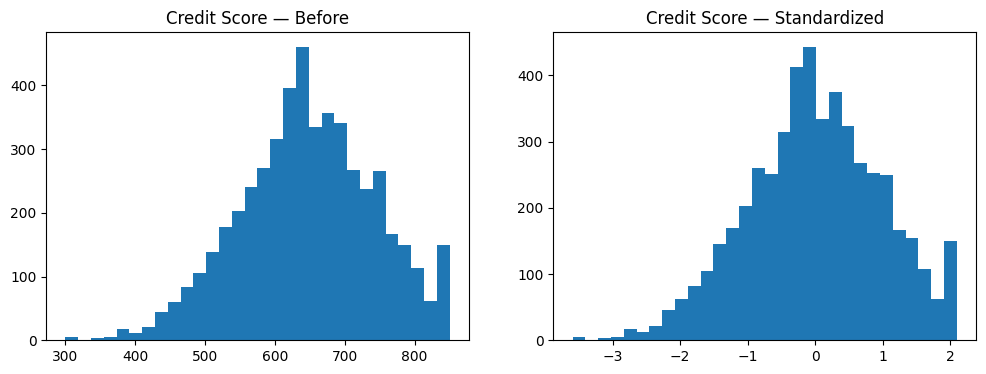

In [147]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df["credit_score"], bins=30)
plt.title("Credit Score — Before")

plt.subplot(1,2,2)
plt.hist(df_transformed["credit_score_standardized"], bins=30)
plt.title("Credit Score — Standardized")

plt.show()


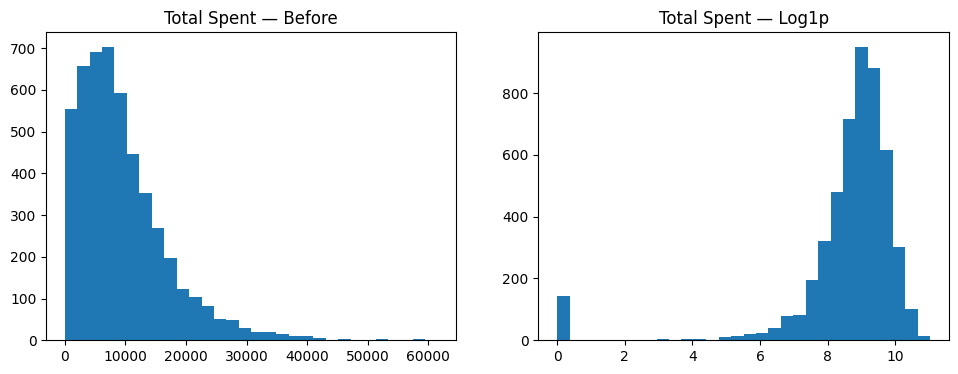

In [148]:
plt.figure(figsize=(18,4))

plt.subplot(1,3,1)
plt.hist(df["total_spent"], bins=30)
plt.title("Total Spent — Before")

plt.subplot(1,3,2)
plt.hist(df_transformed["total_spent_log"], bins=30)
plt.title("Total Spent — Log1p")


plt.show()


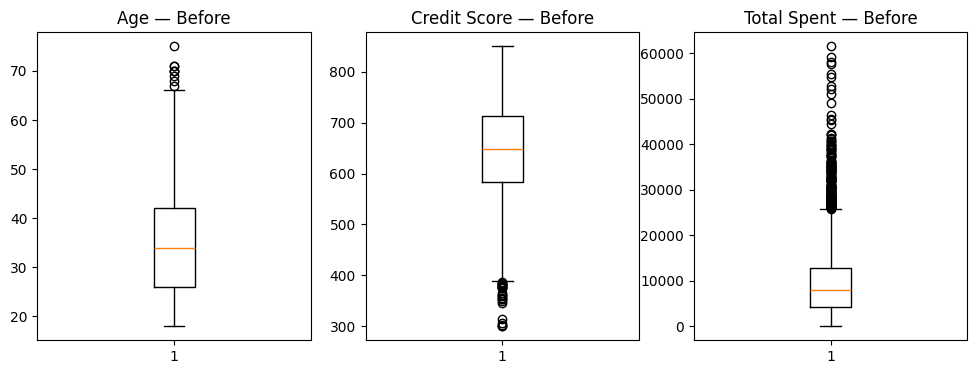

In [150]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.boxplot(df["age"])
plt.title("Age — Before")

plt.subplot(1,3,2)
plt.boxplot(df["credit_score"])
plt.title("Credit Score — Before")

plt.subplot(1,3,3)
plt.boxplot(df["total_spent"])
plt.title("Total Spent — Before")

plt.show()


KeyError: 'total_spent_scaled'

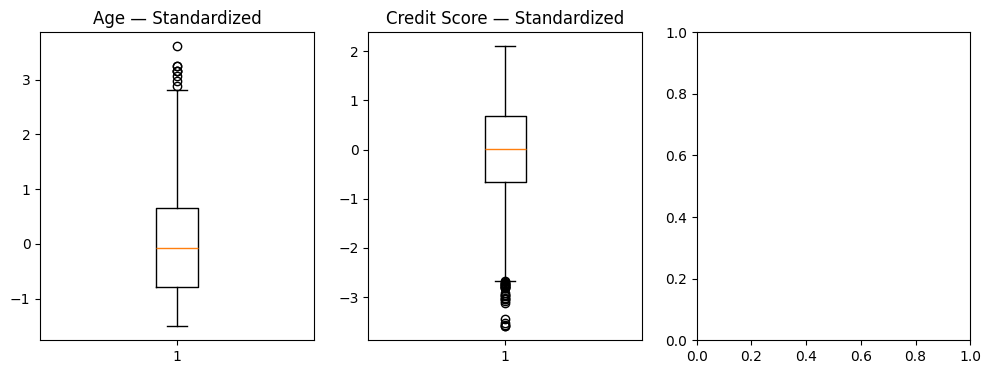

In [151]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.boxplot(df_transformed["age_standardized"])
plt.title("Age — Standardized")

plt.subplot(1,3,2)
plt.boxplot(df_transformed["credit_score_standardized"])
plt.title("Credit Score — Standardized")

plt.subplot(1,3,3)
plt.boxplot(df_transformed["total_spent_scaled"])
plt.title("Total Spent — Scaled")

plt.show()


## 1.5 Feature Engineering

In [ ]:
df_transformed["age_group"] = pd.cut(
    df_transformed["age"],
    bins=[0, 25, 45, 100],
    labels=["Young", "Adult", "Senior"]
)
df_transformed[["age", "age_group"]].head(10)


,age,age_group
0,40.0,Adult
1,29.0,Adult
2,24.0,Young
3,27.0,Adult
4,37.0,Adult
5,33.0,Adult
6,26.0,Adult
7,38.0,Adult
8,39.0,Adult
9,36.0,Adult


In [ ]:
df_transformed["spending_category"] = pd.cut(
    df_transformed["total_spent"],
    bins=[0, 5000, 15000, df_transformed["total_spent"].max()],
    labels=["Low", "Medium", "High"]
)
df_transformed[["total_spent", "spending_category"]].head(10)


,total_spent,spending_category
0,6786.35,Medium
1,11496.74,Medium
2,5959.11,Medium
3,16259.63,High
4,3706.01,Low
5,3533.88,Low
6,12598.18,Medium
7,9231.10,Medium
8,11994.66,Medium
9,6986.04,Medium


In [ ]:
df_transformed["spending_credit_ratio"] = df_transformed["total_spent"] / df_transformed["credit_score"]
df_transformed[["total_spent", "credit_score", "spending_credit_ratio"]].head(10)


,total_spent,credit_score,spending_credit_ratio
0,6786.35,636.0,10.670362
1,11496.74,704.0,16.330597
2,5959.11,508.0,11.730531
3,16259.63,620.0,26.225210
4,3706.01,454.0,8.163018
5,3533.88,619.0,5.709015
6,12598.18,711.0,17.718959
7,9231.10,747.0,12.357564
8,11994.66,585.0,20.503692
9,6986.04,620.0,11.267806


In [ ]:
df_transformed["age_spending_interaction"] = df_transformed["age"] * df_transformed["total_spent"]
df_transformed[["age", "total_spent", "age_spending_interaction"]].head(10)


,age,total_spent,age_spending_interaction
0,40.0,6786.35,271454.00
1,29.0,11496.74,333405.46
2,24.0,5959.11,143018.64
3,27.0,16259.63,439010.01
4,37.0,3706.01,137122.37
5,33.0,3533.88,116618.04
6,26.0,12598.18,327552.68
7,38.0,9231.10,350781.80
8,39.0,11994.66,467791.74
9,36.0,6986.04,251497.44


In [ ]:
df_transformed["log_spending_age"] = df_transformed["total_spent_log"] * df_transformed["age"]
df_transformed[["total_spent_log", "age", "log_spending_age"]].head(10)


,total_spent_log,age,log_spending_age
0,8.822816,40.0,352.912635
1,9.349906,29.0,271.147267
2,8.692844,24.0,208.628261
3,9.696502,27.0,261.805557
4,8.217981,37.0,304.065293
5,8.170435,33.0,269.624343
6,9.441387,26.0,245.476062
7,9.130442,38.0,346.956789
8,9.392300,39.0,366.299708
9,8.851812,36.0,318.665242


In [ ]:
df_transformed = pd.get_dummies(df_transformed, columns=["age_group", "spending_category"], drop_first=True)

## 1.6 Impact Analysis

In [ ]:
df_transformed[[
    "age", "age_group_Adult", "age_group_Senior", 
    "total_spent", "spending_category_Medium", "spending_category_High",
    "spending_credit_ratio", "age_spending_interaction", "log_spending_age"
]].head(10)


,age,age_group_Adult,age_group_Senior,total_spent,spending_category_Medium,spending_category_High,spending_credit_ratio,age_spending_interaction,log_spending_age
0,40.0,True,False,6786.35,True,False,10.670362,271454.00,352.912635
1,29.0,True,False,11496.74,True,False,16.330597,333405.46,271.147267
2,24.0,False,False,5959.11,True,False,11.730531,143018.64,208.628261
3,27.0,True,False,16259.63,False,True,26.225210,439010.01,261.805557
4,37.0,True,False,3706.01,False,False,8.163018,137122.37,304.065293
5,33.0,True,False,3533.88,False,False,5.709015,116618.04,269.624343
6,26.0,True,False,12598.18,True,False,17.718959,327552.68,245.476062
7,38.0,True,False,9231.10,True,False,12.357564,350781.80,346.956789
8,39.0,True,False,11994.66,True,False,20.503692,467791.74,366.299708
9,36.0,True,False,6986.04,True,False,11.267806,251497.44,318.665242


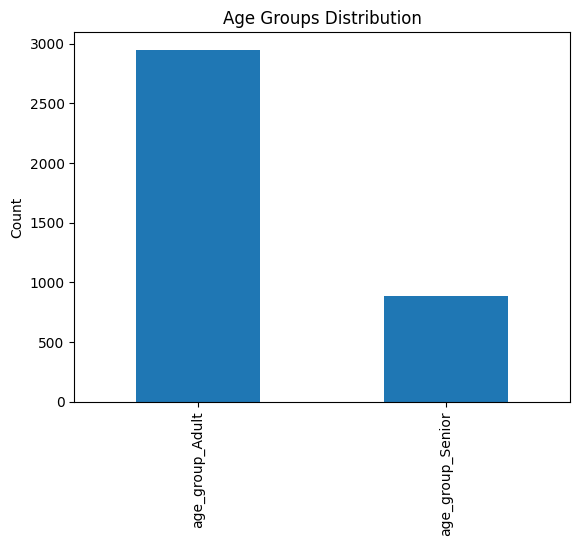

In [ ]:
import matplotlib.pyplot as plt

age_group_cols = ["age_group_Adult", "age_group_Senior"]
df_transformed[age_group_cols].sum().plot(kind="bar")
plt.title("Age Groups Distribution")
plt.ylabel("Count")
plt.show()


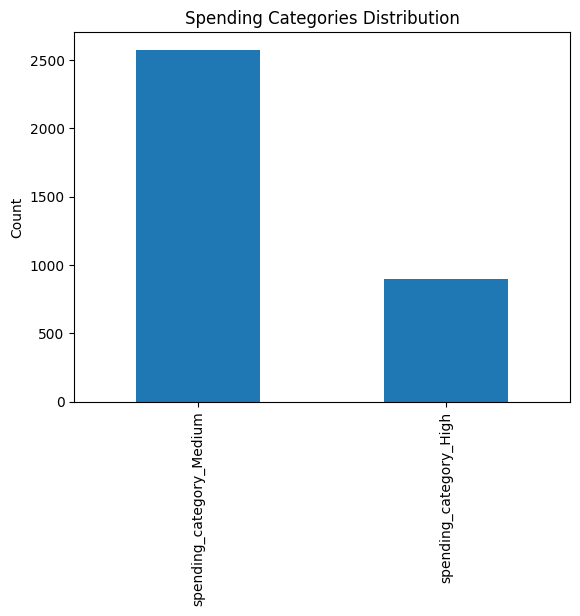

In [ ]:
spending_cat_cols = ["spending_category_Medium", "spending_category_High"]
df_transformed[spending_cat_cols].sum().plot(kind="bar")
plt.title("Spending Categories Distribution")
plt.ylabel("Count")
plt.show()


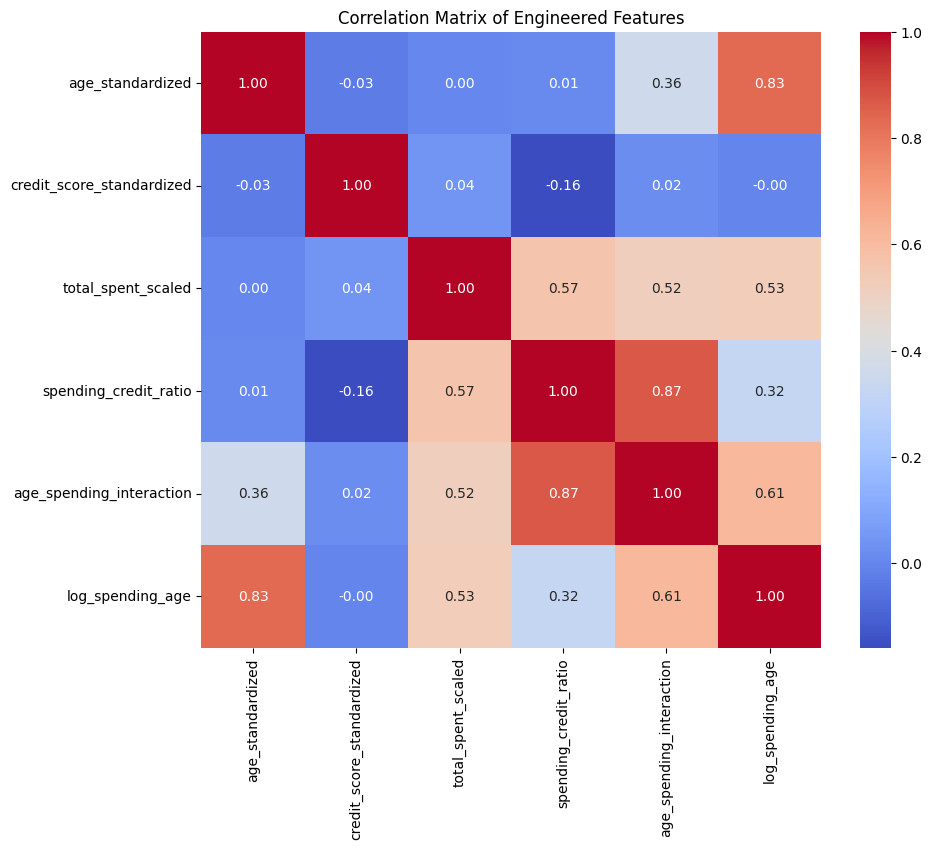

In [ ]:
import seaborn as sns

# Include numeric features and new interaction features
numeric_features = [
    "age_standardized", "credit_score_standardized", "total_spent_scaled",
    "spending_credit_ratio", "age_spending_interaction", "log_spending_age"
]

plt.figure(figsize=(10,8))
sns.heatmap(df_transformed[numeric_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Engineered Features")
plt.show()


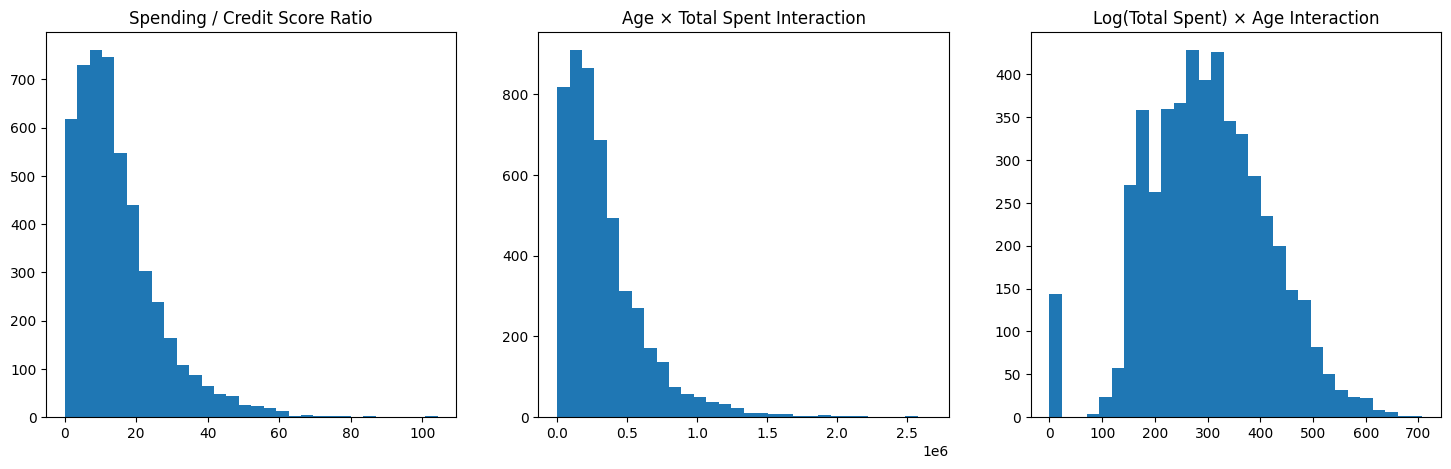

In [ ]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.hist(df_transformed["spending_credit_ratio"], bins=30)
plt.title("Spending / Credit Score Ratio")

plt.subplot(1,3,2)
plt.hist(df_transformed["age_spending_interaction"], bins=30)
plt.title("Age × Total Spent Interaction")

plt.subplot(1,3,3)
plt.hist(df_transformed["log_spending_age"], bins=30)
plt.title("Log(Total Spent) × Age Interaction")

plt.show()


# Dataset02 Order Items

In [ ]:
# Load Dataset02
df_order_items = pd.read_csv('../data/cleaned/cleaned_order_itemsDF.csv')
df_order_items.head()

## 2.1 Outlier Detection & Analysis

In [ ]:
numerical_cols_02 = ['total_price', 'unit_price', 'quantity']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_02):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_order_items[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## 2.2 Data Transformation

In [ ]:
# Log Transformation for total_price
df_order_items['log_total_price'] = np.log1p(df_order_items['total_price'])

# Standardization for unit_price
scaler = StandardScaler()
df_order_items['unit_price_scaled'] = scaler.fit_transform(df_order_items[['unit_price']])

# Visualizing distributions before and after
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df_order_items['total_price'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Total Price Distribution (Original)')

sns.histplot(df_order_items['log_total_price'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Total Price Distribution (Log Transformed)')

sns.histplot(df_order_items['unit_price'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Unit Price Distribution (Original)')

sns.histplot(df_order_items['unit_price_scaled'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Unit Price Distribution (Standardized)')

plt.tight_layout()
plt.show()

## 2.3 Feature Engineering

In [ ]:
# Price Category
df_order_items['price_category'] = pd.qcut(df_order_items['total_price'], q=3, labels=['Low', 'Medium', 'High'])

# Visualizing Price Category
plt.figure(figsize=(8, 5))
sns.countplot(x='price_category', data=df_order_items)
plt.title('Distribution of Price Categories')
plt.show()